<a href="https://colab.research.google.com/github/junaid-pathan/trialforge/blob/main/Hack_Princeton.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install sdv scikit-learn shap captum transformers torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.2/203.2 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 108.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 91.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 11.9 MB/s eta 0:00:00


In [3]:
import pandas as pd
from sdv.single_table import TVAESynthesizer
from sdv.metadata import SingleTableMetadata
from sklearn.model_selection import train_test_split

# 1. Load Real Data (UCI Heart Disease)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
data = pd.read_csv(url, names=names, na_values='?').fillna(0)
data['target'] = (data['target'] > 0).astype(int) # Binary classification

# 2. Step A: The Split (Teacher vs. Judge)
real_a, real_b = train_test_split(data, test_size=0.5, random_state=42)

# 3. Step B: Training the TVAE Synthesizer
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data=real_a)

# Fast training for the hackathon
synthesizer = TVAESynthesizer(metadata, epochs=300, enable_gpu=True)
synthesizer.fit(real_a)

# 4. Generate the Digital Twins
synthetic_a = synthesizer.sample(num_rows=len(real_a))
print("Digital Twins successfully generated!")

/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Digital Twins successfully generated!


In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Prepare Data
X_synth = synthetic_a.drop('target', axis=1)
y_synth = synthetic_a['target']
X_real_test = real_b.drop('target', axis=1)
y_real_test = real_b['target']

# Train on Synthetic (The "Fake Textbook")
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_synth, y_synth)

# Test on Real (The "Locked Box")
predictions = clf.predict(X_real_test)
accuracy = accuracy_score(y_real_test, predictions)

print(f"TSTR Accuracy: {accuracy:.2f}")
print(classification_report(y_real_test, predictions))

TSTR Accuracy: 0.82
              precision    recall  f1-score   support

           0       0.82      0.84      0.83        80
           1       0.81      0.79      0.80        72

    accuracy                           0.82       152
   macro avg       0.82      0.81      0.81       152
weighted avg       0.82      0.82      0.82       152



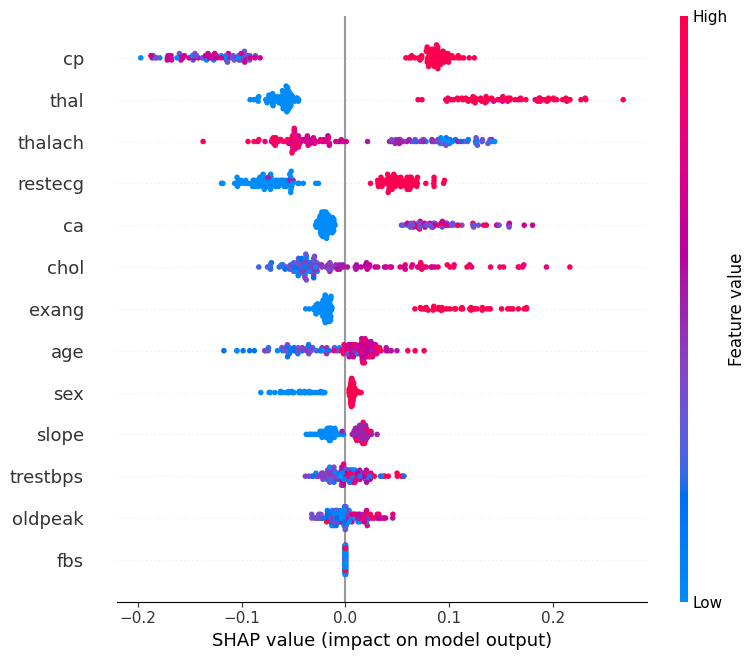

In [6]:
import shap
import numpy as np

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_real_test)

if isinstance(shap_values, list):
    class_1_values = shap_values[1]
elif len(shap_values.shape) == 3:
    class_1_values = shap_values[:, :, 1]
else:
    class_1_values = shap_values

shap.summary_plot(class_1_values, X_real_test)

In [7]:
import torch
from captum.attr import LayerIntegratedGradients
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Use a tiny model as our proxy probe
model_name = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

def predict_path(inputs):
    return model(inputs)[0]

# Proxy Attribution Logic
lig = LayerIntegratedGradients(predict_path, model.distilbert.embeddings)

text = "Patient must undergo bi-weekly biopsies and maintain strict 12-hour fasting."
inputs = tokenizer(text, return_tensors="pt")
input_ids = inputs['input_ids']

# Attribute the 'Risk' output to the words
# (Target 1 = High Risk in this dummy example)
attributions, delta = lig.attribute(inputs=input_ids, target=1, return_convergence_delta=True)

# Visualize the Trigger Words
tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
scores = attributions.sum(dim=-1).squeeze(0).detach().numpy()

for token, score in zip(tokens, scores):
    print(f"Token: {token:12} | Saliency Score: {score:.4f}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Token: [CLS]        | Saliency Score: -0.1888
Token: patient      | Saliency Score: 0.1384
Token: must         | Saliency Score: -0.0052
Token: undergo      | Saliency Score: -0.1316
Token: bi           | Saliency Score: 0.0683
Token: -            | Saliency Score: -0.0994
Token: weekly       | Saliency Score: -0.1123
Token: bio          | Saliency Score: 0.0833
Token: ##ps         | Saliency Score: -0.1123
Token: ##ies        | Saliency Score: -0.0470
Token: and          | Saliency Score: 0.0948
Token: maintain     | Saliency Score: 0.8045
Token: strict       | Saliency Score: 0.5514
Token: 12           | Saliency Score: -0.2584
Token: -            | Saliency Score: 0.0098
Token: hour         | Saliency Score: 0.0827
Token: fast         | Saliency Score: -0.2998
Token: ##ing        | Saliency Score: -0.0136
Token: .            | Saliency Score: 0.1264
Token: [SEP]        | Saliency Score: -0.0770


/tmp/ipykernel_7092/3368080259.py:16: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr-1), (kcorr-1)))
/tmp/ipykernel_7092/3368080259.py:16: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr-1), (kcorr-1)))
/tmp/ipykernel_7092/3368080259.py:16: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr-1), (kcorr-1)))
/tmp/ipykernel_7092/3368080259.py:16: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr-1), (kcorr-1)))
/tmp/ipykernel_7092/3368080259.py:16: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr-1), (kcorr-1)))
/tmp/ipykernel_7092/3368080259.py:16: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr-1), (kcorr-1)))
/tmp/ipykernel_7092/3368080259.py:16: RuntimeWarning: invalid value encountered in scala

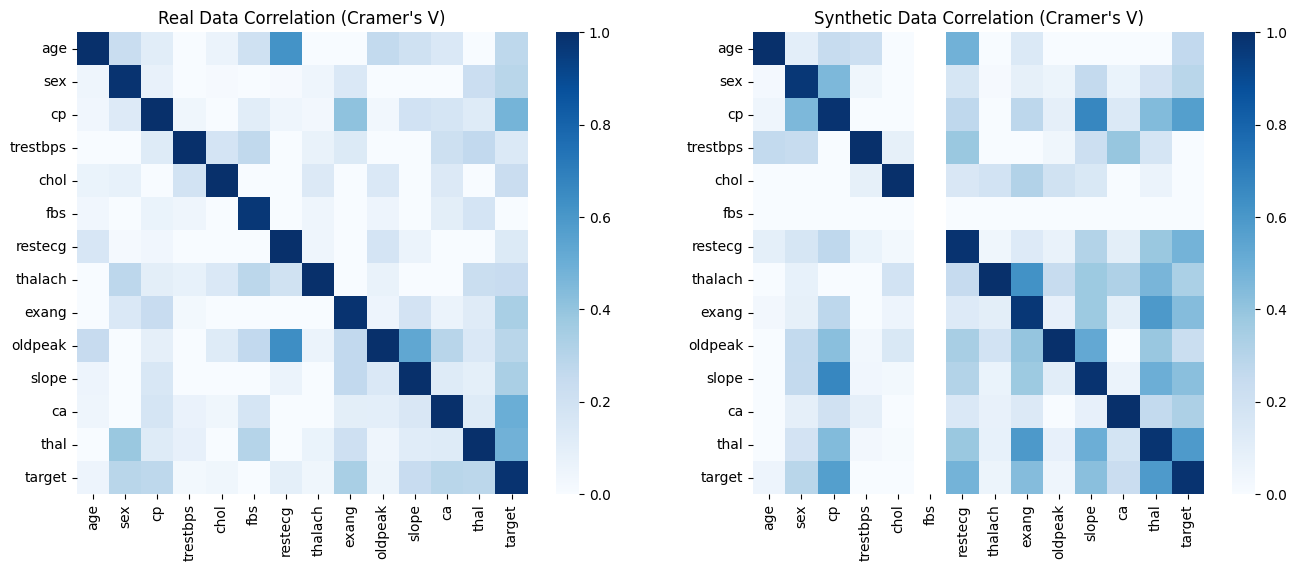

In [8]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """Calculates Cramer's V for two categorical or binned variables."""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1)) / (n-1))
    rcorr = r - ((r-1)**2) / (n-1)
    kcorr = k - ((k-1)**2) / (n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (kcorr-1)))

def get_correlation_matrix(df):
    cols = df.columns
    matrix = pd.DataFrame(np.zeros((len(cols), len(cols))), index=cols, columns=cols)
    for i in cols:
        for j in cols:
            matrix.loc[i, j] = cramers_v(df[i], df[j])
    return matrix

# 1. Generate Matrices
real_corr = get_correlation_matrix(real_a)
synth_corr = get_correlation_matrix(synthetic_a)

# 2. Visualize the Comparison (The Fidelity Test)
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(real_corr, annot=False, cmap='Blues', ax=ax[0])
ax[0].set_title("Real Data Correlation (Cramer's V)")

sns.heatmap(synth_corr, annot=False, cmap='Blues', ax=ax[1])
ax[1].set_title("Synthetic Data Correlation (Cramer's V)")
plt.show()

## Personalized Digital Twins (Latent Perturbation)

Rather than sampling the whole latent cloud, we **encode one real patient** into TVAE latent space, then perturb their coordinates with Gaussian noise to generate N variations that share their identity but differ in uncertain biological response. These twins feed the visualize/ UI as the patient's personal probability map.


In [ ]:
from personalized_twins import PersonalizedTwinGenerator, risk_probability_map

# The patient from the visualize/ form (example values from the UCI schema)
patient = {
    "age": 62, "sex": 1, "cp": 3, "trestbps": 140, "chol": 250,
    "fbs": 0, "restecg": 1, "thalach": 150, "exang": 0,
    "oldpeak": 1.4, "slope": 2, "ca": 0, "thal": 3, "target": 0,
}

gen = PersonalizedTwinGenerator(synthesizer)
mu, std = gen.encode(__import__("pandas").DataFrame([patient]))
print(f"Patient latent vector shape: {mu.shape}  (first 5 dims: {mu[0][:5].round(3)})")


In [ ]:
twins = gen.generate_twins(patient, n_twins=100, noise_scale=0.1, seed=42)
print(f"Generated {len(twins)} personalized twins")
twins.head()


In [ ]:
risk = risk_probability_map(twins, clf)
print(f"Personal probability map for this patient:")
print(f"  Mean risk:       {risk["mean_risk"]:.2%}")
print(f"  % twins at risk: {risk["pct_at_risk"]:.1f}%")
print(f"  80% band:        [{risk["p10"]:.2%}, {risk["p90"]:.2%}]")


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4))
plt.hist(risk["risk_scores"], bins=20, edgecolor="black")
plt.axvline(0.5, color="red", linestyle="--", label="risk threshold")
plt.axvline(risk["mean_risk"], color="green", linestyle="-", label=f"mean = {risk["mean_risk"]:.2%}")
plt.title(f"Risk distribution across 100 personalized twins (patient age {patient["age"]})")
plt.xlabel("Predicted risk probability")
plt.ylabel("Twin count")
plt.legend()
plt.show()


### What-if: tighter vs. broader twins

Lower noise_scale = twins that look almost identical to the patient (useful for showing a narrow prognosis band). Higher = a wider exploration of nearby outcomes. Expose this as a slider in the UI to let patients see "variations of me".


In [ ]:
for scale in [0.05, 0.15, 0.30]:
    t = gen.generate_twins(patient, n_twins=100, noise_scale=scale, seed=7)
    r = risk_probability_map(t, clf)
    print(f"noise_scale={scale:.2f}  mean_risk={r["mean_risk"]:.2%}  pct_at_risk={r["pct_at_risk"]:.1f}%  band=[{r["p10"]:.2%}, {r["p90"]:.2%}]")
